In [1]:
import pandas as pd
scores = [['Alice',70,80,85,'アメリカ','中1','10分'],['Shohei',95,78,70,'日本','中2','30分'],['Bob',65,85,97,'カナダ','中1','15分']
,['Charlie',90,95,100,'イギリス','中3','5分'],['Mamiko',80,75,90,'日本','中1','10分'],['Peter',65,85,90,'ドイツ','中2','15分']]
score_df = pd.DataFrame(scores, index = ['AL','SH','BO','CH','MA','PE'],columns=['名前','国語','数学','英語','国籍','学年','通学時間'])
score_df


,名前,国語,数学,英語,国籍,学年,通学時間
AL,Alice,70,80,85,アメリカ,中1,10分
SH,Shohei,95,78,70,日本,中2,30分
BO,Bob,65,85,97,カナダ,中1,15分
CH,Charlie,90,95,100,イギリス,中3,5分
MA,Mamiko,80,75,90,日本,中1,10分
PE,Peter,65,85,90,ドイツ,中2,15分


# 1. DataFrameからの条件抽出
英語のスコアが90以上の生徒を抽出せよ

,名前,国語,数学,英語,国籍,学年,通学時間
BO,Bob,65,85,97,カナダ,中1,15分
CH,Charlie,90,95,100,イギリス,中3,5分
MA,Mamiko,80,75,90,日本,中1,10分
PE,Peter,65,85,90,ドイツ,中2,15分


国籍が日本以外でかつ、国語のスコアが70以上の生徒を抽出せよ

,名前,国語,数学,英語,国籍,学年,通学時間
AL,Alice,70,80,85,アメリカ,中1,10分
CH,Charlie,90,95,100,イギリス,中3,5分


# 2.演算処理
国語、数学、英語それぞれのスコア合計および平均を求めよ

国語    465
数学    498
英語    532
dtype: int64

国語    77.500000
数学    83.000000
英語    88.666667
dtype: float64

国語のスコアの平均を求めよ

77.5

学年が中1または中2の生徒の数学のスコア平均を求めよ

80.6

# 3. グルーピング
学年毎の国語、数学、英語のそれぞれ平均を計算せよ

,国語,数学,英語
学年,,,
中1,71.666667,80.0,90.666667
中2,80.000000,81.5,80.000000
中3,90.000000,95.0,100.000000


In [ ]:
上表について、学年毎の国語、数学、英語の平均を計算せよ

学年
中1    80.777778
中2    80.500000
中3    95.000000
dtype: float64

groupbyで集約したdataframeの中身は、以下の通り、集約に使ったcolumnをキーとして、その値毎のサブdataframeとなっていることがわかる
そこで、学年の取りうる値をkey、それに対応するサブdataframeをvalueとする辞書型(Json)を作成せよ  
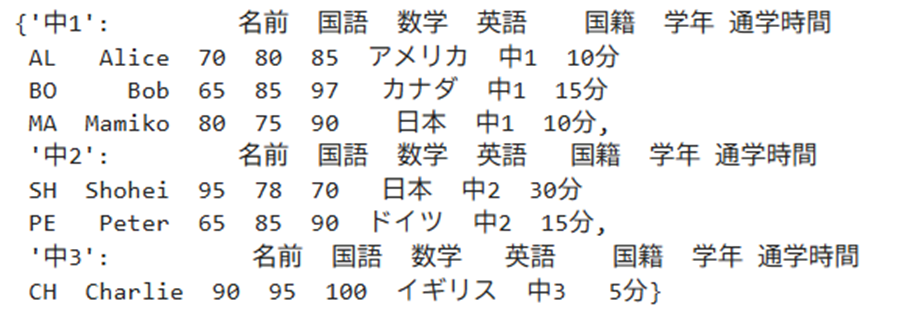

In [28]:
for k,sub_df in score_df.groupby('学年'):
    print(k)
    print(sub_df)

中1
        名前  国語  数学  英語    国籍  学年 通学時間
AL   Alice  70  80  85  アメリカ  中1  10分
BO     Bob  65  85  97   カナダ  中1  15分
MA  Mamiko  80  75  90    日本  中1  10分
中2
        名前  国語  数学  英語   国籍  学年 通学時間
SH  Shohei  95  78  70   日本  中2  30分
PE   Peter  65  85  90  ドイツ  中2  15分
中3
         名前  国語  数学   英語    国籍  学年 通学時間
CH  Charlie  90  95  100  イギリス  中3   5分


{'中1':         名前  国語  数学  英語    国籍  学年 通学時間
 AL   Alice  70  80  85  アメリカ  中1  10分
 BO     Bob  65  85  97   カナダ  中1  15分
 MA  Mamiko  80  75  90    日本  中1  10分,
 '中2':         名前  国語  数学  英語   国籍  学年 通学時間
 SH  Shohei  95  78  70   日本  中2  30分
 PE   Peter  65  85  90  ドイツ  中2  15分,
 '中3':          名前  国語  数学   英語    国籍  学年 通学時間
 CH  Charlie  90  95  100  イギリス  中3   5分}

**例2. profile_dfをhobby毎に平均をとる**

# 4. データの更新
Shoheiの英語のスコアを90に更新せよ

,名前,国語,数学,英語,国籍,学年,通学時間
AL,Alice,70,80,85,アメリカ,中1,10分
SH,Shohei,95,78,90,日本,中2,30分
BO,Bob,65,85,97,カナダ,中1,15分
CH,Charlie,90,95,100,イギリス,中3,5分
MA,Mamiko,80,75,90,日本,中1,10分
PE,Peter,65,85,90,ドイツ,中2,15分


# 5. 行毎繰り返し処理
score_dfを1行つづ読んで、名前、国語スコアを表示せよ

Alice 70.0
Shohei 95.0
Bob 65.0
Charlie 90.0
Mamiko 80.0
Peter 65.0
nan nan


score_dfを1行づつ読んで、中1の生徒のデータのみ表示せよ

名前      Alice
国語         70
数学         80
英語         85
国籍       アメリカ
学年         中1
通学時間      10分
Name: AL, dtype: object
名前      Bob
国語       65
数学       85
英語       97
国籍      カナダ
学年       中1
通学時間    15分
Name: BO, dtype: object
名前      Mamiko
国語          80
数学          75
英語          90
国籍          日本
学年          中1
通学時間       10分
Name: MA, dtype: object


上記3.グルーピングで作成したJsonをfor分で逐次読みだして、サブdataframeを表示せよ


        名前  国語  数学  英語    国籍  学年 通学時間
AL   Alice  70  80  85  アメリカ  中1  10分
BO     Bob  65  85  97   カナダ  中1  15分
MA  Mamiko  80  75  90    日本  中1  10分
        名前  国語  数学  英語   国籍  学年 通学時間
SH  Shohei  95  78  70   日本  中2  30分
PE   Peter  65  85  90  ドイツ  中2  15分
         名前  国語  数学   英語    国籍  学年 通学時間
CH  Charlie  90  95  100  イギリス  中3   5分
